In [53]:
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
import pandas as pd
import torch
import torch.optim as optim
torch.set_printoptions(precision=4)

matr = read_complex_matrix('ref_matrix.txt')
import timeit


import warnings

#warnings.filterwarnings("ignore", category=UserWarning, message="To copy construct from a tensor")

In [54]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [55]:
%%time
q = dynamic_mesh_q(kmax, Ndots, gap)

r, r_conv= reflectometry(q, matr)

x_crit, y_max, x_max, y_min, x_min = reflectometry_trace(q, matr) 

CPU times: total: 172 ms
Wall time: 184 ms


In [56]:
len(r)

62

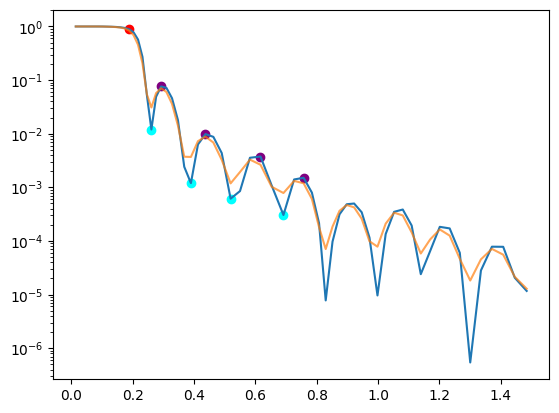

In [57]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.plot(q.cpu().detach().numpy()[0:len(r.tolist())]*1e-9, r.tolist())
ax.plot(q.cpu().detach().numpy()[0:len(r_conv.tolist())]*1e-9, r_conv.tolist(), alpha=0.7)
ax.scatter(x_max.cpu().detach().numpy()*1e-9, y_max.cpu().detach().numpy(), color = 'purple')
ax.scatter(x_min.cpu().detach().numpy()*1e-9, y_min.cpu().detach().numpy(), color = 'cyan')
ax.scatter(x_crit.cpu().detach().numpy()*1e-9, 0.9, color = 'red')

ax.set_yscale('log')

plt.show()

In [82]:
class Comparator:
    def __init__(self, q, orig_matr):
        self.q = q
        self.orig_matr = orig_matr
        
    def compare(self, var_matr):
        # ВАРИАНТ 1: Вычисляем reference каждый раз (медленно, но правильно)
        r1, r_conv1 = reflectometry(self.q, self.orig_matr)
        r2, r_conv2 = reflectometry(self.q, var_matr)
        
        diff = r1 - r2
        ratio = diff / torch.pow(r1, 0.875)
        squared = diff ** 2
        loss = torch.sum(squared)
    
        return loss

    def compare_weightless(self, var_matr):
        r1, r_conv1 = reflectometry(self.q, self.orig_matr)
        r2, r_conv2 = reflectometry(self.q, var_matr)
        
        diff = r1 - r2
        ratio = diff/r1
        squared = diff ** 2
        loss = torch.sum(squared)
    
        return loss

    def compare_trace(self, var_matr):
        crit1, r_max1, q_max1, r_min1, q_min1 =  reflectometry_trace(self.q, self.orig_matr)
        crit2, r_max2, q_max2, r_min2, q_min2 =  reflectometry_trace(self.q, var_matr)

        loss = (2*len(r_max1)*(crit1-crit2)/crit1)**2 + torch.sum(((r_max1-r_max2)/r_max1)**2) + torch.sum(((q_max1-q_max2)/q_max1)**2) + torch.sum(((q_min1-q_min2)/q_min1)**2)
        
        return loss


loss_function = Comparator(q, matr)

<span style="font-size:24px;">Фактически, домножаем квадраты относительного отклонения на веса ниже:</span>

In [83]:
torch.pow(r, 0.25)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9997, 0.9985, 0.9972,
        0.9952, 0.9915, 0.9846, 0.9705, 0.9394, 0.8692, 0.7218, 0.4773, 0.3308,
        0.4704, 0.5252, 0.5177, 0.4631, 0.3658, 0.2218, 0.1860, 0.2818, 0.3149,
        0.3058, 0.2570, 0.1574, 0.1708, 0.2443, 0.2476, 0.1815, 0.1322, 0.1935,
        0.1971, 0.1680, 0.1210, 0.0528, 0.0993, 0.1331, 0.1483, 0.1495, 0.1361,
        0.1037, 0.0557, 0.1077, 0.1367, 0.1402, 0.1180, 0.0700, 0.0898, 0.1164,
        0.1144, 0.0880, 0.0271, 0.0728, 0.0940, 0.0939, 0.0674, 0.0585],
       device='cuda:0', dtype=torch.float64, grad_fn=<PowBackward0>)

In [84]:
all_bounds = torch.tensor([[[10.00, 10.00], [0.00, 0.00], [0.000, 0.000]],
                           [[320.0, 450.0], [7.60, 8.40], [30.00, 50.00]],
                           [[100.0, 200.0], [-2.2, -1.8], [16.00, 28.00]],
                           [[10.00, 10.00], [2.00, 2.00], [0.000, 0.000]]]).requires_grad_(True) 

In [85]:
torch.manual_seed(42)

In [86]:
matrixx = torch.round((all_bounds[:, :, 1] - all_bounds[:, :, 0])*torch.rand(tuple(all_bounds.shape[:-1]))+all_bounds[:, :, 0], decimals=1)
indices = (all_bounds[..., 0] != all_bounds[..., 1]).flatten().nonzero().squeeze()
initial_guess = matrixx.flatten()[indices]
initial_guess

tensor([444.7000,   7.9000,  42.0000, 125.7000,  -1.9000,  27.3000],
       grad_fn=<IndexBackward0>)

In [87]:
valid_bounds = all_bounds[(all_bounds[..., 0] != all_bounds[..., 1])]
mask_d = []
mask_rho = []
for i in range(len(valid_bounds)):
    if i%3 == 1: mask_rho.append(i)
    else: mask_d.append(i)
rho_bounds = valid_bounds[mask_rho]
d_bounds = valid_bounds[mask_d]

In [88]:
#initial_guess = torch.tensor([350.0, 8.2, 30.0, 250.00,-2.1, 20.0]).requires_grad_(True)

In [89]:
class varbounds:
    def __init__(self, bounds_tensor, loss_func):
        self.loss = loss_func
        self.bounds = bounds_tensor
        self.mask = self.bounds[..., 0] != self.bounds[..., 1]
        flat_mask = self.mask.flatten()
        self.indices_flat = flat_mask.nonzero().squeeze()
        
    def objective_function(self, var_vector_d, var_vector_rho):
        var_vector = torch.cat((var_vector_d.reshape(-1, 2), var_vector_rho.reshape(-1, 1)), dim=1)[:,torch.tensor([0, 2, 1])].flatten()
        
        flat_base = self.bounds[..., 0].flatten()
        result = flat_base.scatter(0, self.indices_flat, var_vector)
        target_shape = self.bounds[..., 0].shape
        viewed_result = result.view_as(self.bounds[..., 0])
        final_result = self.loss(viewed_result)

        return final_result

    def objective_function_trace(self, var_vector_d, var_vector_rho):
        var_vector = torch.cat((var_vector_d.reshape(-1, 2), var_vector_rho.reshape(-1, 1)), dim=1)[:,torch.tensor([0, 2, 1])].flatten()
        
        flat_base = self.bounds[..., 0].flatten()
        result = flat_base.scatter(0, self.indices_flat, var_vector)
        target_shape = self.bounds[..., 0].shape
        viewed_result = result.view_as(self.bounds[..., 0])
        final_result = self.loss(viewed_result)
        
        return final_result

objective_function = varbounds(all_bounds, loss_function.compare)
objective_function_trace = varbounds(all_bounds, loss_function.compare_trace)
objective_function_weighless = varbounds(all_bounds, loss_function.compare_weightless)

In [90]:
initial_d = torch.tensor([444.7000,  42.0000, 125.7000,  27.3000], requires_grad=True)
initial_rho = torch.tensor([7.9000,  -1.9000], requires_grad=True)

In [91]:
objective_function.objective_function(initial_d, initial_rho)

tensor(0.0245, device='cuda:0', dtype=torch.float64, grad_fn=<SumBackward0>)

In [92]:
objective_function_trace.objective_function(initial_d, initial_rho)

tensor(1.3518, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>)

In [93]:
objective_function_weighless.objective_function(initial_d, initial_rho)

tensor(0.0245, device='cuda:0', dtype=torch.float64, grad_fn=<SumBackward0>)

In [94]:
def repair_matrix(bounds, vector):
       mask = bounds[..., 0] != bounds[..., 1]
       flat_mask = mask.flatten()
       indices_flat = flat_mask.nonzero().squeeze()
       flat_base = bounds[..., 0].flatten()
       result = flat_base.scatter(0, indices_flat, vector)
       target_shape = bounds[..., 0].shape
       viewed_result = result.view_as(bounds[..., 0])
       return viewed_result

def twin_plotter(matr, q, r):
    r2, r_conv2 = reflectometry(q, matr)
    fig, ax = plt.subplots(figsize=(15, 2.6))

    ax.plot(q.cpu().detach().numpy()[0:len(r.tolist())]*1e-9, r.tolist())
    ax.plot(q.cpu().detach().numpy()[0:len(r2.tolist())]*1e-9, r2.tolist())

    ax.set_yscale('log')

    plt.show()

In [95]:
import torch.optim as optim

def adamw(func, initial_d, initial_rho, d_bounds, rho_bounds, lr=1.2, max_iter=2510, tol=1e-18, k=10):
    k -= 1
    
    x_d = initial_d.clone().detach().requires_grad_(True)
    x_rho = initial_rho.clone().detach().requires_grad_(True)

    optimizer = optim.AdamW([
        {'params': x_d, 'lr': lr, 'weight_decay': 0, 'betas': (0.8, 0.99)},
        {'params': x_rho, 'lr': lr/1000, 'weight_decay': 0, 'betas': (0.8, 0.99)}
    ])
    
    # Планировщик для exp уменьшения lr
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.984)
    prev_loss = None
    rel_losses = []
    
    # Вычисляем начальное значение функции потерь для расчета относительной потери
    # Убедитесь, что func(initial_d, initial_rho) возвращает скалярный тензор
    initial_loss_value = func(initial_d, initial_rho).item()
    
    for i in range(max_iter):
        # Полный сброс градиентов
        optimizer.zero_grad(set_to_none=True)
        
        try:
            # Вычисляем функцию потерь с новым графом, передавая оба тензора
            with torch.enable_grad():
                current_loss = func(x_d, x_rho)
            
            # Вычисляем градиенты
            current_loss.backward()
            
            # Обновляем параметры
            optimizer.step()

            with torch.no_grad():
                x_d.data = torch.clamp(x_d.data, d_bounds[:,0], d_bounds[:,1])
                x_rho.data = torch.clamp(x_rho.data, rho_bounds[:, 0], rho_bounds[:, 1])
            
            # Обновляем learning rate
            scheduler.step()

            rel_losses.append((current_loss / initial_loss_value).item())
            
            if i % int((max_iter - 1) / k) == 0:
                # Для вывода и repair_matrix объединяем оптимизированные тензоры
                combined_x_for_print = torch.cat((x_d.reshape(-1, 2), x_rho.reshape(-1, 1)), dim=1)[:,torch.tensor([0, 2, 1])].flatten()
                
                print("relative_loss:  ", (current_loss / initial_loss_value).item(), "\n",
                      "var_vector_d:  ", x_d.detach(), "\n",
                      "var_vector_rho:  ", x_rho.detach(), "\n",
                      "grad_d:  ", x_d.grad, "\n",
                      "grad_rho:  ", x_rho.grad, "\n",
                      "learning_rate:  ", optimizer.param_groups[0]['lr'],  "\n",
                      "iteration:  ", i + 1,  "\n")
                # Предполагается, что repair_matrix ожидает объединенный тензор
                twin_plotter(repair_matrix(all_bounds, combined_x_for_print), q, r)
        
        except RuntimeError as e:
            print(f"Ошибка на итерации {i}: {str(e)}")
            print("Текущее значение x_d:", x_d.detach())
            print("Текущее значение x_rho:", x_rho.detach())
            print("Градиент x_d:", x_d.grad)
            print("Градиент x_rho:", x_rho.grad)
            print("Текущий loss:", current_loss)
            print("Текущий LR:", optimizer.param_groups[0]['lr'])
            raise
        
        # Проверка сходимости
        if prev_loss is not None and abs(prev_loss - current_loss.item()) < tol and i >= 50:
            print(f"Converged at iteration {i}")
            break
            
        prev_loss = current_loss.item()
    
    # Возвращаем оптимизированные тензоры и другие результаты
    return x_d.detach(), x_rho.detach(), current_loss.item(), rel_losses

relative_loss:   0.9999999999999999 
 var_vector_d:   tensor([444.3000,  42.4000, 125.3000,  26.9000]) 
 var_vector_rho:   tensor([ 7.9004, -1.9004]) 
 grad_d:   tensor([ 9.2288e-04, -5.5980e-04,  9.3172e-05,  3.9614e-04]) 
 grad_rho:   tensor([-0.0788,  0.0043]) 
 learning_rate:   0.4 
 iteration:   1 



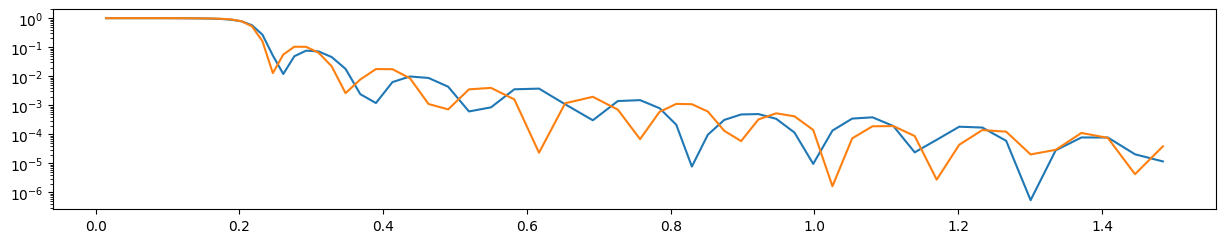

relative_loss:   0.008459470082925646 
 var_vector_d:   tensor([407.7786,  50.0000, 141.9432,  16.0000]) 
 var_vector_rho:   tensor([ 7.9600, -1.9684]) 
 grad_d:   tensor([ 6.5806e-06, -7.3204e-06, -2.5188e-06,  5.5999e-06]) 
 grad_rho:   tensor([-0.0103,  0.0011]) 
 learning_rate:   0.25877817693064575 
 iteration:   279 



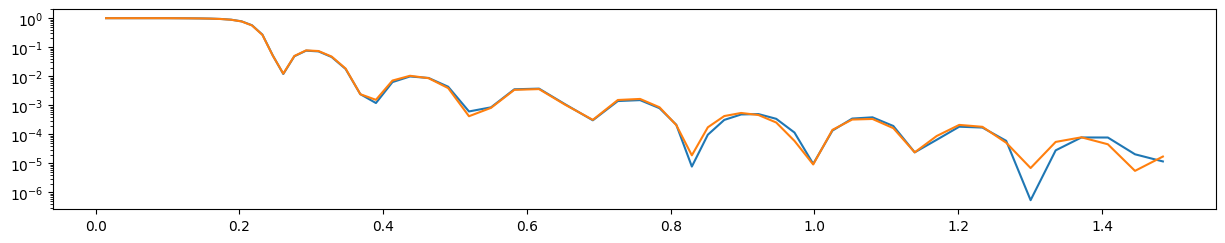

relative_loss:   0.0005137306069161272 
 var_vector_d:   tensor([407.4327,  50.0000, 147.9477,  16.0000]) 
 var_vector_rho:   tensor([ 7.9865, -1.9999]) 
 grad_d:   tensor([-5.1003e-08, -6.1573e-07, -2.1329e-07,  3.5867e-07]) 
 grad_rho:   tensor([-0.0024,  0.0002]) 
 learning_rate:   0.16473671634464954 
 iteration:   557 



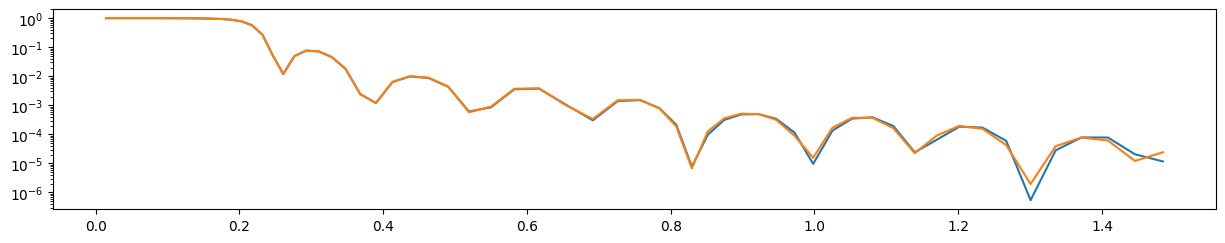

relative_loss:   3.4354619923979836e-05 
 var_vector_d:   tensor([407.3992,  49.9165, 149.7266,  16.0000]) 
 var_vector_rho:   tensor([ 7.9948, -2.0092]) 
 grad_d:   tensor([ 7.3529e-08,  8.2840e-08, -9.4496e-09,  2.6573e-08]) 
 grad_rho:   tensor([-1.1948e-04,  1.4121e-05]) 
 learning_rate:   0.10487045713785492 
 iteration:   835 



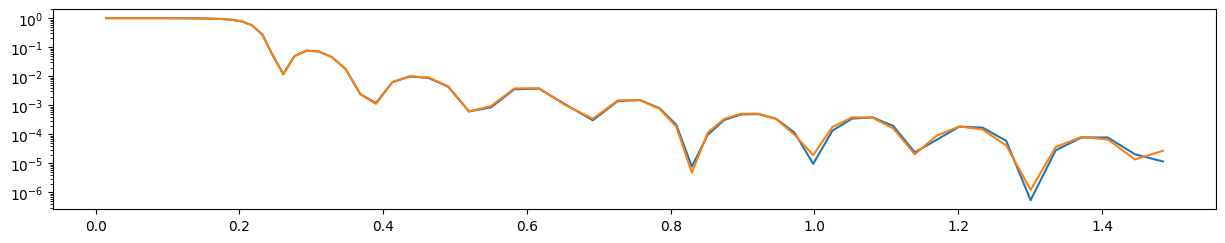

relative_loss:   2.7591858845647744e-05 
 var_vector_d:   tensor([406.9135,  49.0596, 149.7118,  16.0000]) 
 var_vector_rho:   tensor([ 7.9955, -2.0104]) 
 grad_d:   tensor([8.8238e-08, 9.4358e-08, 2.0820e-09, 1.5301e-08]) 
 grad_rho:   tensor([-7.9307e-06,  2.3998e-06]) 
 learning_rate:   0.06675993685156313 
 iteration:   1113 



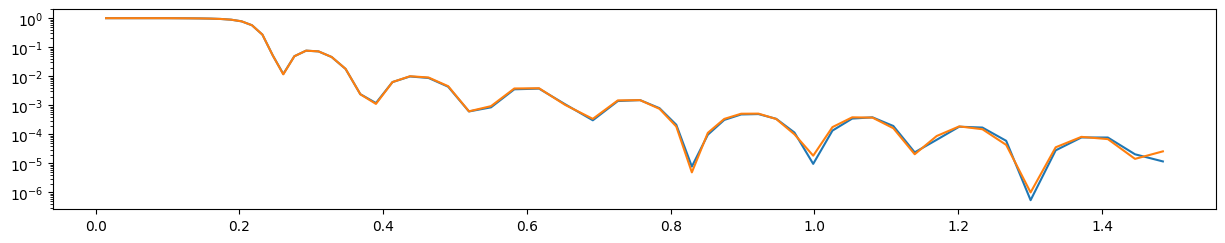

relative_loss:   1.764113146075772e-05 
 var_vector_d:   tensor([405.8525,  47.1945, 149.4754,  16.0000]) 
 var_vector_rho:   tensor([ 7.9960, -2.0118]) 
 grad_d:   tensor([6.5901e-08, 7.3629e-08, 1.5260e-09, 7.6308e-09]) 
 grad_rho:   tensor([-5.5627e-06,  1.3027e-06]) 
 learning_rate:   0.04249899628611326 
 iteration:   1391 



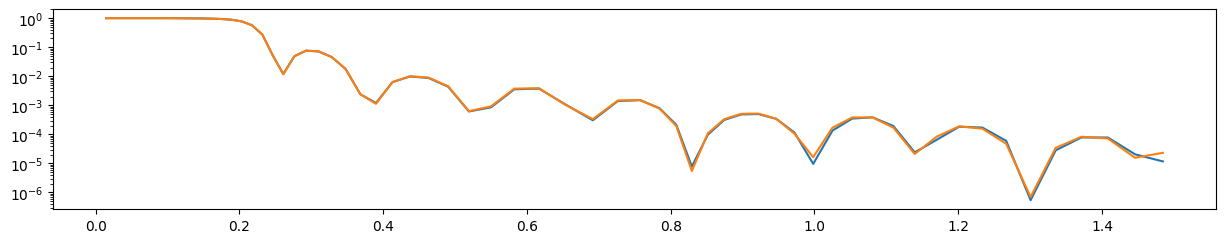

relative_loss:   7.238701762044076e-06 
 var_vector_d:   tensor([404.2010,  44.3149, 149.1180,  16.0223]) 
 var_vector_rho:   tensor([ 7.9968, -2.0127]) 
 grad_d:   tensor([ 3.4904e-08,  4.3308e-08,  5.9091e-10, -2.0955e-09]) 
 grad_rho:   tensor([-3.4823e-06, -1.3222e-07]) 
 learning_rate:   0.027494531950756695 
 iteration:   1669 



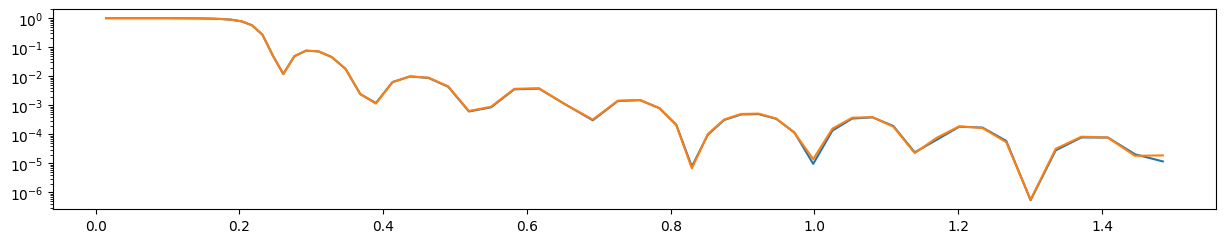

relative_loss:   2.133500314682717e-06 
 var_vector_d:   tensor([402.4930,  41.7981, 149.0197,  16.6493]) 
 var_vector_rho:   tensor([ 7.9979, -2.0100]) 
 grad_d:   tensor([ 2.2208e-08,  1.2935e-08,  1.0104e-09, -2.9689e-09]) 
 grad_rho:   tensor([-1.9672e-06, -9.2375e-07]) 
 learning_rate:   0.017502862740294396 
 iteration:   1947 



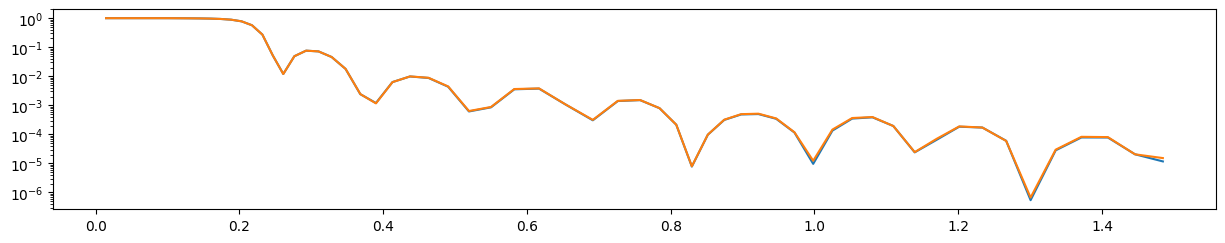

relative_loss:   6.2384834250736e-07 
 var_vector_d:   tensor([401.3128,  40.5313, 149.2355,  17.6958]) 
 var_vector_rho:   tensor([ 7.9989, -2.0062]) 
 grad_d:   tensor([ 9.3594e-09,  3.1389e-09, -5.0383e-10, -3.7404e-09]) 
 grad_rho:   tensor([-3.7716e-07, -9.6236e-07]) 
 learning_rate:   0.011142222921061746 
 iteration:   2225 



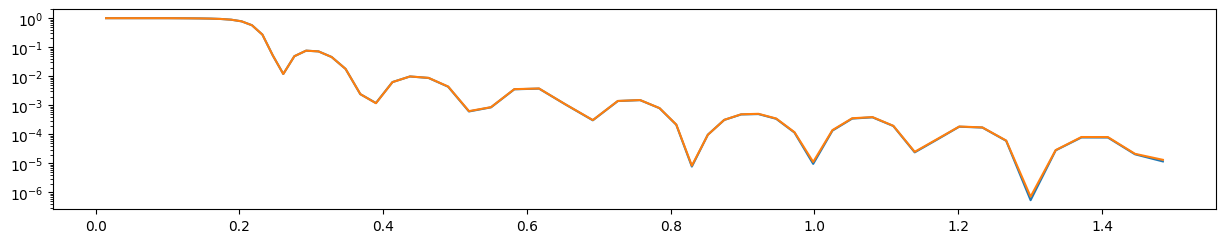

relative_loss:   2.494033187148097e-07 
 var_vector_d:   tensor([400.7698,  40.1271, 149.4408,  18.4105]) 
 var_vector_rho:   tensor([ 7.9993, -2.0039]) 
 grad_d:   tensor([ 1.2519e-08, -4.6635e-09,  1.1403e-09, -1.4042e-10]) 
 grad_rho:   tensor([-7.0317e-07, -7.0491e-07]) 
 learning_rate:   0.007093075770789346 
 iteration:   2503 



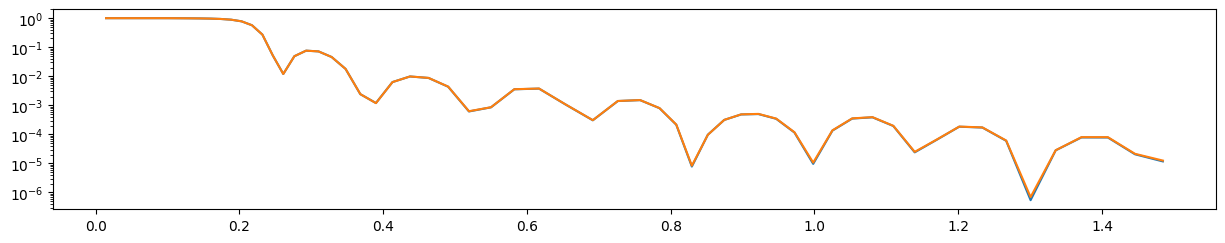

CPU times: total: 3min 2s
Wall time: 2min 59s


In [106]:
%%time
ans_d, ans_rho, loss, rel_losses1 = adamw(objective_function.objective_function_trace, initial_d, initial_rho, d_bounds, rho_bounds, lr=0.4)

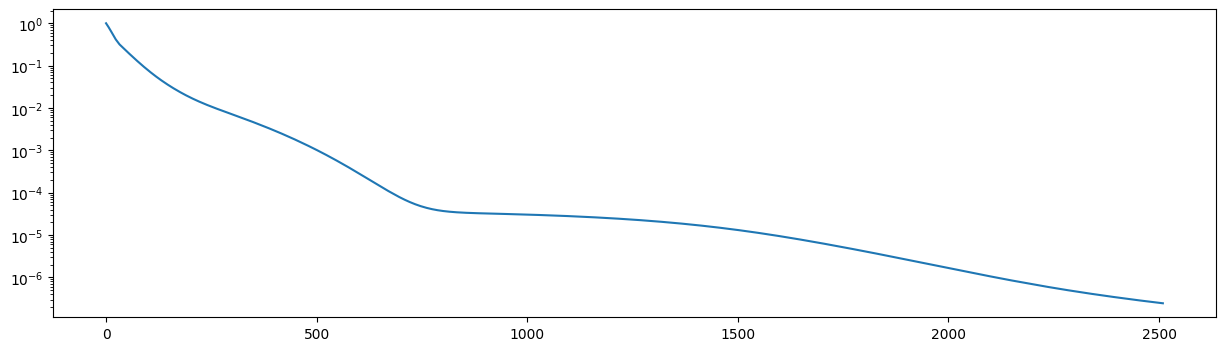

In [108]:
fig, ax = plt.subplots(figsize =(15, 4))

#ax.plot(range(0,len(rel_losses)), rel_losses)
ax.plot(range(0,len(rel_losses1)), rel_losses1)

ax.set_yscale('log')

plt.show()

relative_loss:   0.9999999999999999 
 var_vector_d:   tensor([443.5000,  43.2000, 124.5001,  26.1000]) 
 var_vector_rho:   tensor([ 7.9012, -1.9012]) 
 grad_d:   tensor([ 9.2288e-04, -5.5980e-04,  9.3172e-05,  3.9614e-04]) 
 grad_rho:   tensor([-0.0788,  0.0043]) 
 learning_rate:   1.2 
 iteration:   1 



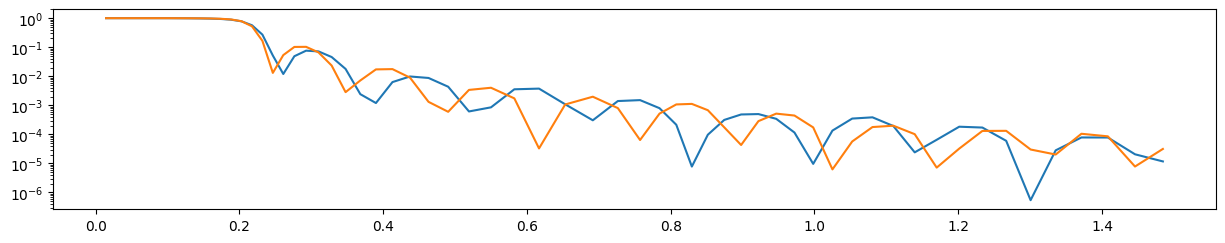

relative_loss:   4.229181839538649e-05 
 var_vector_d:   tensor([407.4130,  49.9957, 149.6158,  16.0000]) 
 var_vector_rho:   tensor([ 7.9935, -2.0135]) 
 grad_d:   tensor([ 4.2422e-08,  3.8350e-08, -5.2068e-08,  5.4438e-08]) 
 grad_rho:   tensor([-3.1685e-04,  3.3312e-05]) 
 learning_rate:   0.7763345307919376 
 iteration:   279 



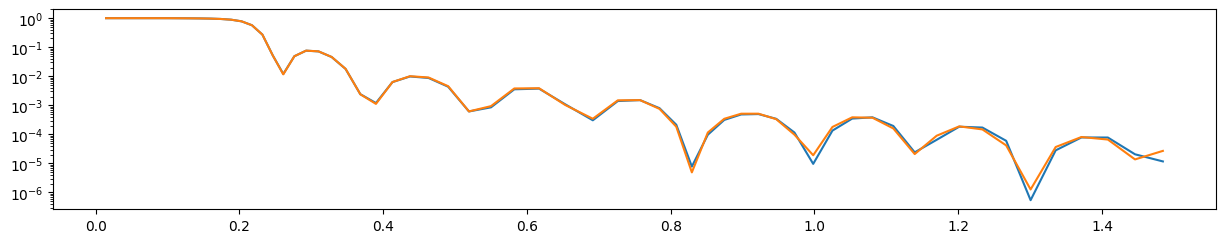

relative_loss:   2.816060031295185e-05 
 var_vector_d:   tensor([406.9720,  49.2246, 149.8033,  16.0000]) 
 var_vector_rho:   tensor([ 7.9949, -2.0158]) 
 grad_d:   tensor([8.8368e-08, 9.6253e-08, 1.7089e-09, 1.3810e-08]) 
 grad_rho:   tensor([-3.9127e-06,  1.4890e-06]) 
 learning_rate:   0.4942101490339491 
 iteration:   557 



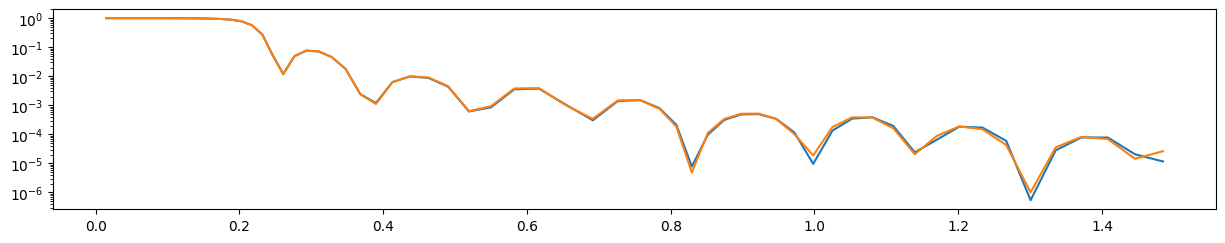

relative_loss:   1.8560686657612563e-05 
 var_vector_d:   tensor([405.9545,  47.4363, 149.5765,  16.0000]) 
 var_vector_rho:   tensor([ 7.9953, -2.0173]) 
 grad_d:   tensor([6.9998e-08, 7.3575e-08, 1.7360e-09, 7.8862e-09]) 
 grad_rho:   tensor([-3.8936e-06,  6.3247e-07]) 
 learning_rate:   0.31461137141356504 
 iteration:   835 



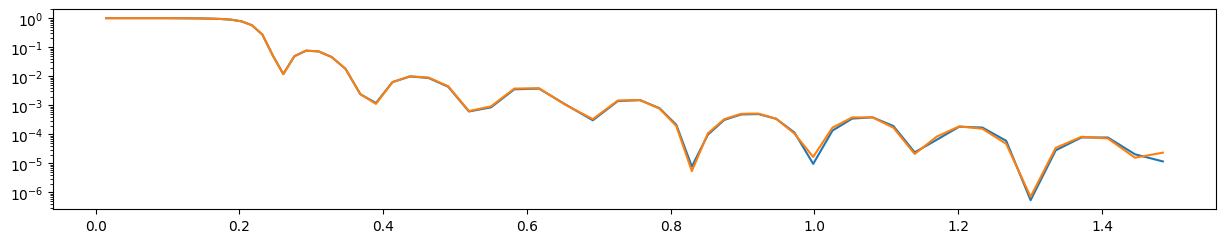

relative_loss:   7.566847657665137e-06 
 var_vector_d:   tensor([404.2281,  44.4036, 149.1797,  16.0135]) 
 var_vector_rho:   tensor([ 7.9963, -2.0170]) 
 grad_d:   tensor([ 4.0096e-08,  3.9730e-08,  1.2815e-09, -8.8838e-10]) 
 grad_rho:   tensor([-3.5340e-06, -5.8537e-07]) 
 learning_rate:   0.2002798105546895 
 iteration:   1113 



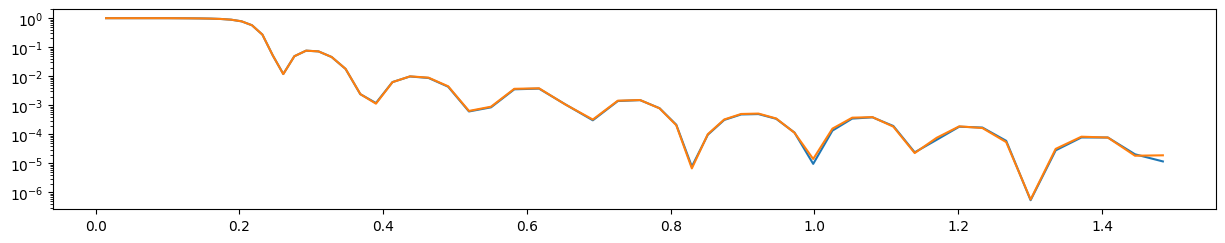

relative_loss:   2.0272251041476313e-06 
 var_vector_d:   tensor([402.2091,  41.3899, 148.9590,  16.7037]) 
 var_vector_rho:   tensor([ 7.9982, -2.0090]) 
 grad_d:   tensor([ 6.2695e-07, -3.6599e-07,  1.3486e-07,  2.2428e-07]) 
 grad_rho:   tensor([-3.3637e-05,  6.3963e-08]) 
 learning_rate:   0.1274969888583398 
 iteration:   1391 



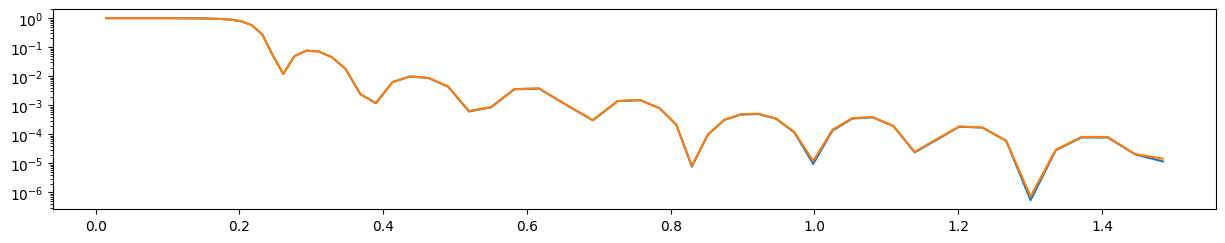

relative_loss:   3.3996633575701334e-07 
 var_vector_d:   tensor([401.1498,  40.2154, 149.1200,  17.7470]) 
 var_vector_rho:   tensor([ 7.9997, -1.9989]) 
 grad_d:   tensor([ 1.0148e-07, -5.4938e-08,  1.9133e-08,  3.3114e-08]) 
 grad_rho:   tensor([-5.2219e-06, -1.0356e-07]) 
 learning_rate:   0.08248359585227008 
 iteration:   1669 



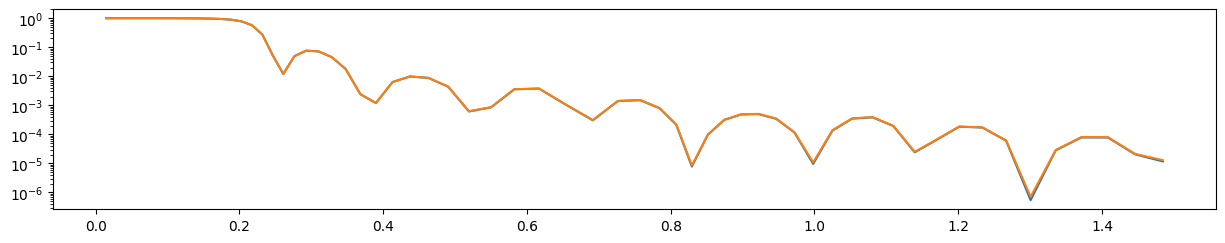

relative_loss:   1.1604679071679503e-07 
 var_vector_d:   tensor([400.6644,  39.8579, 149.3079,  18.4046]) 
 var_vector_rho:   tensor([ 8.0001, -1.9965]) 
 grad_d:   tensor([-1.8068e-09,  3.7965e-09, -1.3948e-09, -3.8987e-09]) 
 grad_rho:   tensor([ 2.2282e-07, -1.1178e-08]) 
 learning_rate:   0.05250858822088321 
 iteration:   1947 



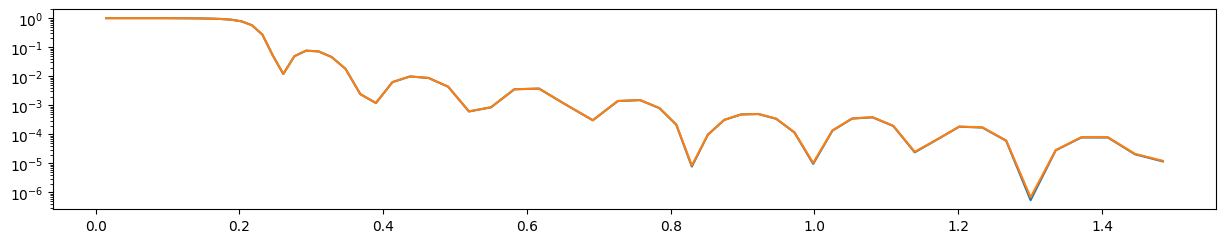

relative_loss:   5.6403322458286206e-08 
 var_vector_d:   tensor([400.4226,  39.8032, 149.4884,  18.8605]) 
 var_vector_rho:   tensor([ 8.0002, -1.9970]) 
 grad_d:   tensor([ 2.2779e-08, -1.3137e-08,  3.9366e-09,  6.5721e-09]) 
 grad_rho:   tensor([-1.0673e-06,  4.1479e-08]) 
 learning_rate:   0.03342666876318528 
 iteration:   2225 



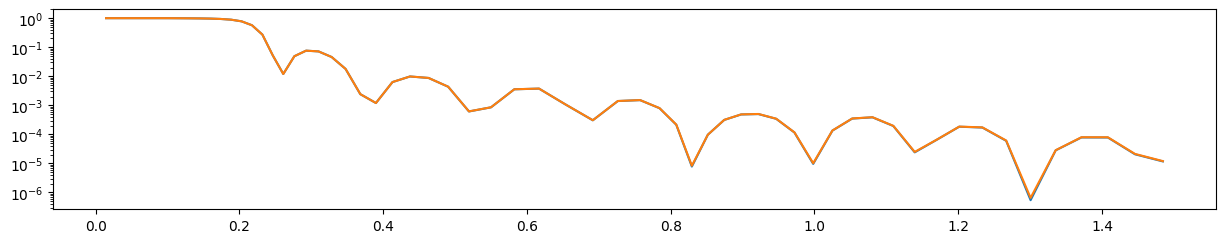

relative_loss:   3.245577487965716e-08 
 var_vector_d:   tensor([400.2841,  39.8315, 149.6296,  19.1867]) 
 var_vector_rho:   tensor([ 8.0002, -1.9977]) 
 grad_d:   tensor([ 6.3505e-08, -3.8753e-08,  1.2034e-08,  2.2951e-08]) 
 grad_rho:   tensor([-3.2085e-06,  9.7621e-08]) 
 learning_rate:   0.02127922731236806 
 iteration:   2503 



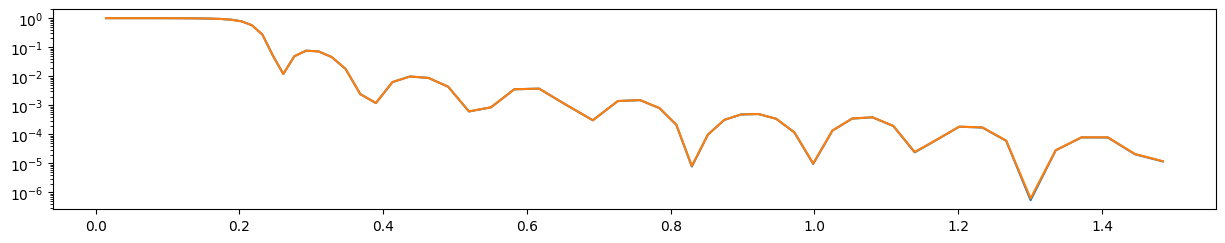

CPU times: total: 3min 1s
Wall time: 2min 58s


In [107]:
%%time
ans_d, ans_rho, loss, rel_losses2 = adamw(objective_function.objective_function, initial_d, initial_rho, d_bounds, rho_bounds)

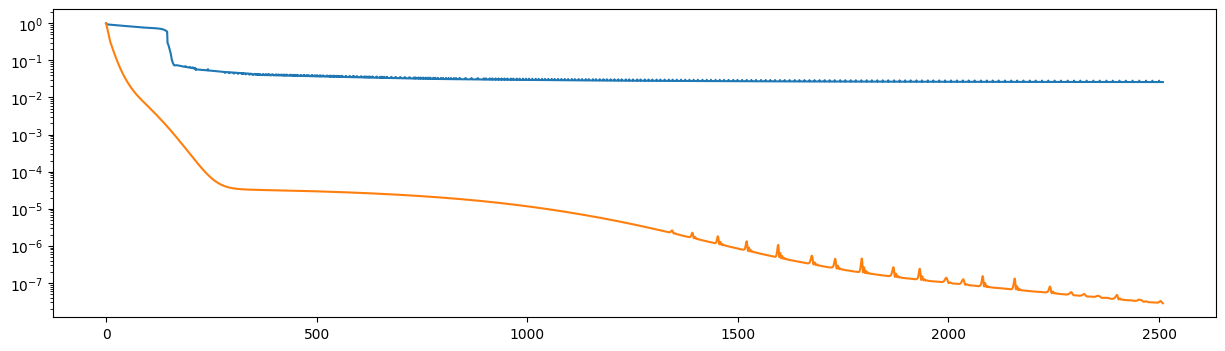

In [27]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses1)), rel_losses1)
ax.plot(range(0,len(rel_losses2)), rel_losses2)

ax.set_yscale('log')

plt.show()

relative_loss:   0.9999999999999999 
 var_vector_d:   tensor([443.5000,  43.2000, 124.5001,  26.1000]) 
 var_vector_rho:   tensor([ 7.9012, -1.9012]) 
 grad_d:   tensor([ 9.2288e-04, -5.5980e-04,  9.3172e-05,  3.9614e-04]) 
 grad_rho:   tensor([-0.0788,  0.0043]) 
 learning_rate:   1.2 
 iteration:   1 



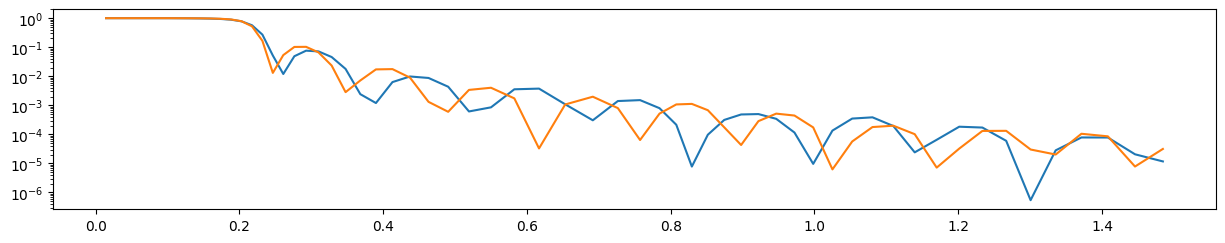

relative_loss:   0.00030346416457648014 
 var_vector_d:   tensor([407.4296,  50.0000, 148.3775,  16.0000]) 
 var_vector_rho:   tensor([ 7.9883, -2.0068]) 
 grad_d:   tensor([ 1.0450e-08, -4.1472e-07, -2.8082e-07,  3.2638e-07]) 
 grad_rho:   tensor([-0.0018,  0.0002]) 
 learning_rate:   0.8691269457638 
 iteration:   200 



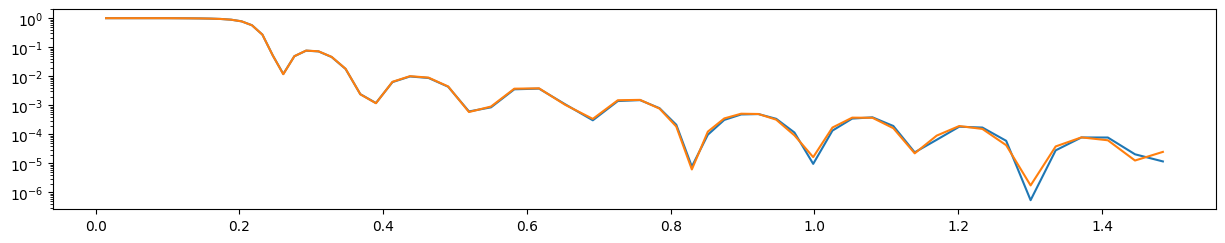

relative_loss:   3.163450498562623e-05 
 var_vector_d:   tensor([407.2852,  49.7752, 149.8666,  16.0000]) 
 var_vector_rho:   tensor([ 7.9947, -2.0152]) 
 grad_d:   tensor([9.4228e-08, 1.0139e-07, 6.0209e-10, 1.7082e-08]) 
 grad_rho:   tensor([-1.0690e-05,  2.4361e-06]) 
 learning_rate:   0.6397202302275672 
 iteration:   399 



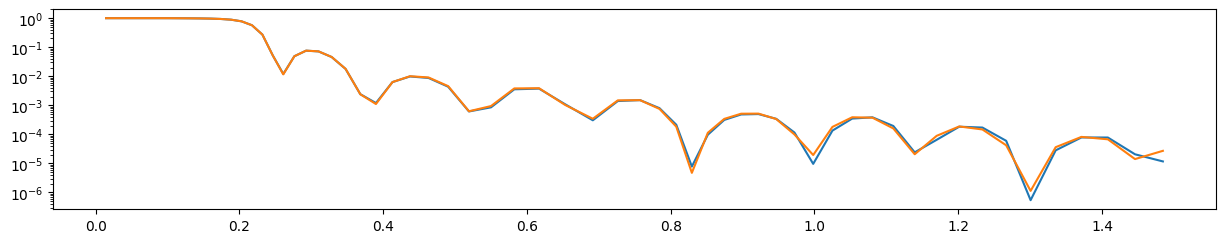

In [178]:
ans_d, ans_rho, loss, rel_losses3 = adamw(objective_function.objective_function, initial_d, initial_rho, d_bounds, rho_bounds, lr=1.2, max_iter=400, tol=1e-18, k=3)

relative_loss:   1.0 
 var_vector_d:   tensor([407.2023,  49.6906, 149.8585,  16.0000]) 
 var_vector_rho:   tensor([ 7.9948, -2.0153]) 
 grad_d:   tensor([9.4822e-08, 1.0100e-07, 9.7489e-10, 1.7169e-08]) 
 grad_rho:   tensor([-1.0379e-05,  2.4022e-06]) 
 learning_rate:   0.09 
 iteration:   1 



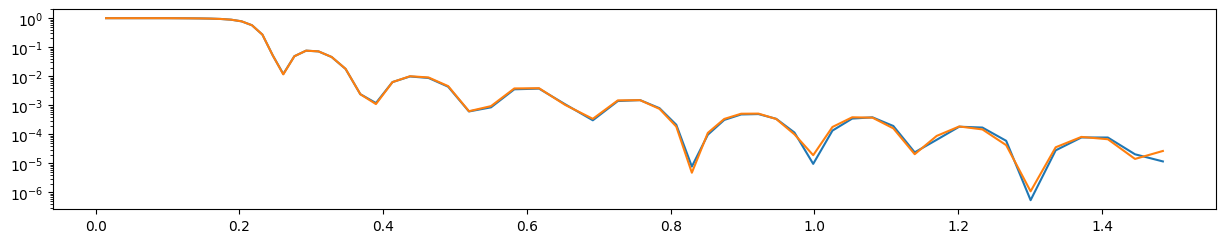

relative_loss:   0.14471990949729022 
 var_vector_d:   tensor([403.4492,  43.2217, 149.0930,  16.3055]) 
 var_vector_rho:   tensor([ 7.9972, -2.0126]) 
 grad_d:   tensor([ 5.1652e-09,  4.4380e-08, -3.5601e-09, -1.2340e-08]) 
 grad_rho:   tensor([-4.9377e-07, -7.3114e-07]) 
 learning_rate:   0.059171839237190334 
 iteration:   263 



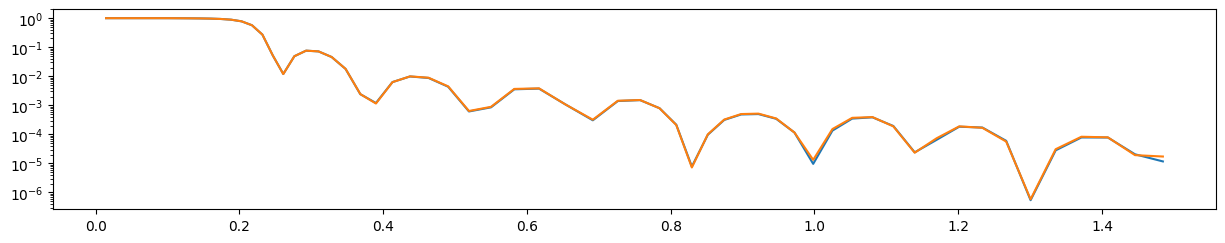

relative_loss:   0.02187359918817789 
 var_vector_d:   tensor([401.6082,  40.6799, 149.0330,  17.3079]) 
 var_vector_rho:   tensor([ 7.9993, -2.0012]) 
 grad_d:   tensor([ 3.5735e-08, -8.3084e-09,  5.1434e-09,  6.1335e-09]) 
 grad_rho:   tensor([-1.9933e-06, -3.3304e-07]) 
 learning_rate:   0.03890340620790999 
 iteration:   525 



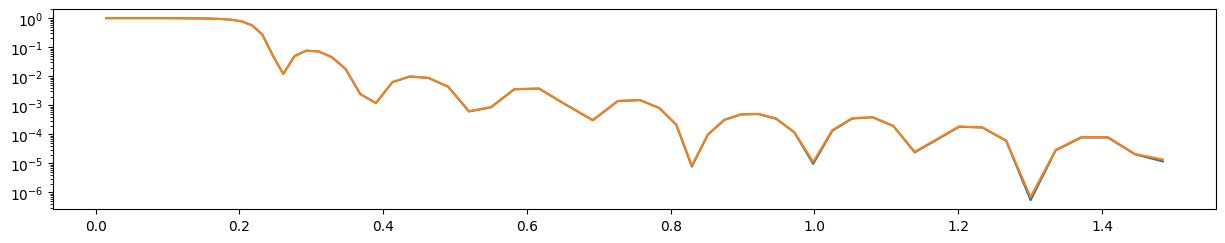

relative_loss:   0.006129497028471577 
 var_vector_d:   tensor([400.8910,  39.9732, 149.1869,  18.0512]) 
 var_vector_rho:   tensor([ 8.0000, -1.9969]) 
 grad_d:   tensor([-9.6989e-09,  1.0609e-08, -3.2140e-09, -7.9424e-09]) 
 grad_rho:   tensor([ 4.0701e-07, -6.6454e-08]) 
 learning_rate:   0.025577623310150708 
 iteration:   787 



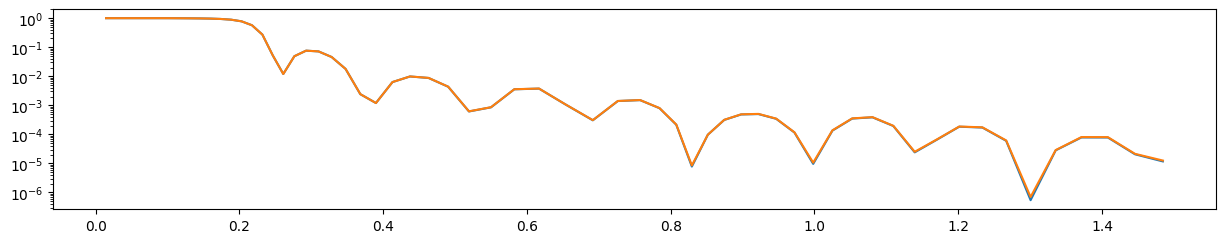

relative_loss:   0.002873978859224851 
 var_vector_d:   tensor([400.5614,  39.7922, 149.3575,  18.5516]) 
 var_vector_rho:   tensor([ 8.0002, -1.9964]) 
 grad_d:   tensor([ 3.4873e-09, -4.1142e-10, -6.4865e-10, -1.2937e-09]) 
 grad_rho:   tensor([ 2.9405e-07, -3.4603e-08]) 
 learning_rate:   0.016816389050862777 
 iteration:   1049 



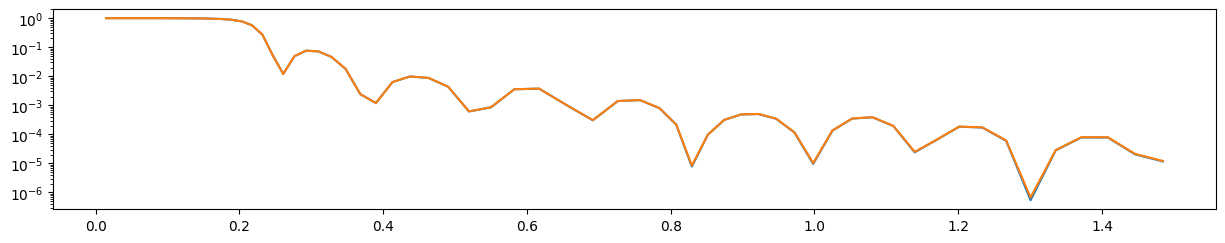

relative_loss:   0.0016366145010662536 
 var_vector_d:   tensor([400.3920,  39.7800, 149.5011,  18.8998]) 
 var_vector_rho:   tensor([ 8.0002, -1.9970]) 
 grad_d:   tensor([ 7.6732e-09, -4.0521e-09,  3.6068e-10,  1.0942e-09]) 
 grad_rho:   tensor([ 2.3413e-08, -2.2149e-08]) 
 learning_rate:   0.010879286252846862 
 iteration:   1311 



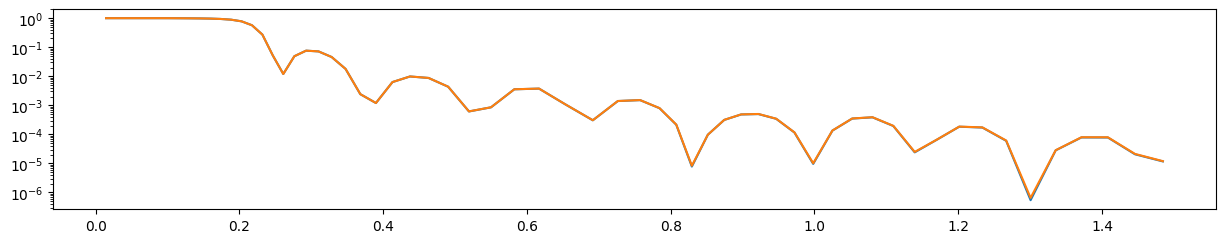

relative_loss:   0.0010262934624419785 
 var_vector_d:   tensor([400.2980,  39.8053, 149.6030,  19.1321]) 
 var_vector_rho:   tensor([ 8.0002, -1.9975]) 
 grad_d:   tensor([ 7.6296e-10, -2.3819e-10, -6.0369e-10, -1.1875e-09]) 
 grad_rho:   tensor([ 1.2586e-07, -5.1273e-09]) 
 learning_rate:   0.007152748635209218 
 iteration:   1573 



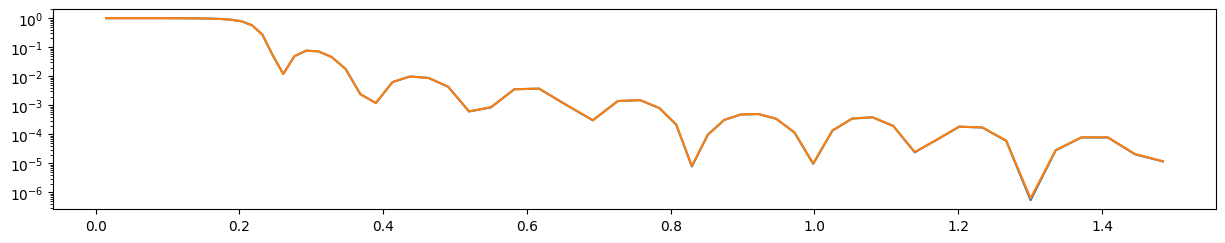

relative_loss:   0.0007146075517464348 
 var_vector_d:   tensor([400.2433,  39.8302, 149.6687,  19.2785]) 
 var_vector_rho:   tensor([ 8.0001, -1.9979]) 
 grad_d:   tensor([ 3.9104e-10, -1.5252e-10, -4.9088e-10, -1.0922e-09]) 
 grad_rho:   tensor([7.1662e-08, 1.7699e-09]) 
 learning_rate:   0.004702681026073695 
 iteration:   1835 



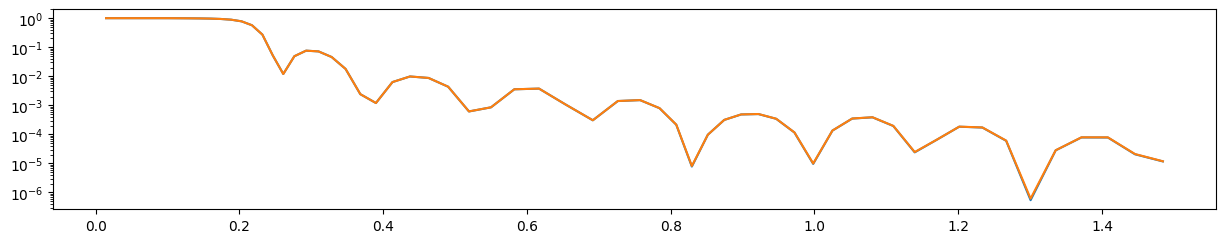

relative_loss:   0.0005515840951889976 
 var_vector_d:   tensor([400.2114,  39.8478, 149.7091,  19.3676]) 
 var_vector_rho:   tensor([ 8.0001, -1.9982]) 
 grad_d:   tensor([ 2.1554e-10, -1.2262e-10, -4.1320e-10, -1.0102e-09]) 
 grad_rho:   tensor([-1.6532e-08,  1.0504e-08]) 
 learning_rate:   0.003091847618429089 
 iteration:   2097 



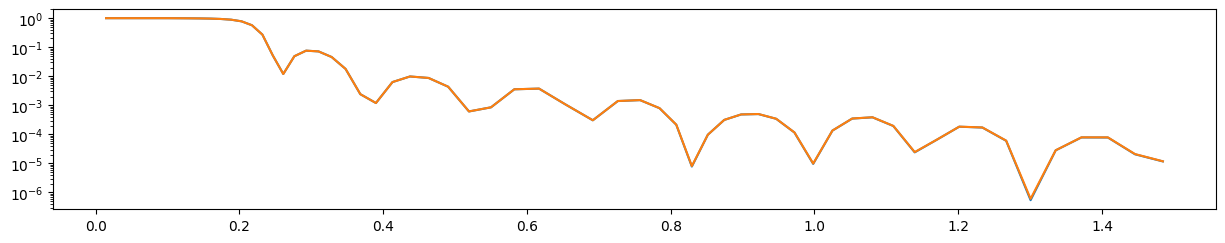

In [179]:
ans_d, ans_rho, loss, rel_losses3_1 = adamw(objective_function.objective_function, ans_d, ans_rho, d_bounds, rho_bounds, lr=0.09, max_iter=2100, tol=1e-18, k=9)

In [180]:
rel_losses3_1 = list(map(lambda x: x * rel_losses3[-1],  rel_losses3_1))
rel_losses3_2 = rel_losses3 + rel_losses3_1

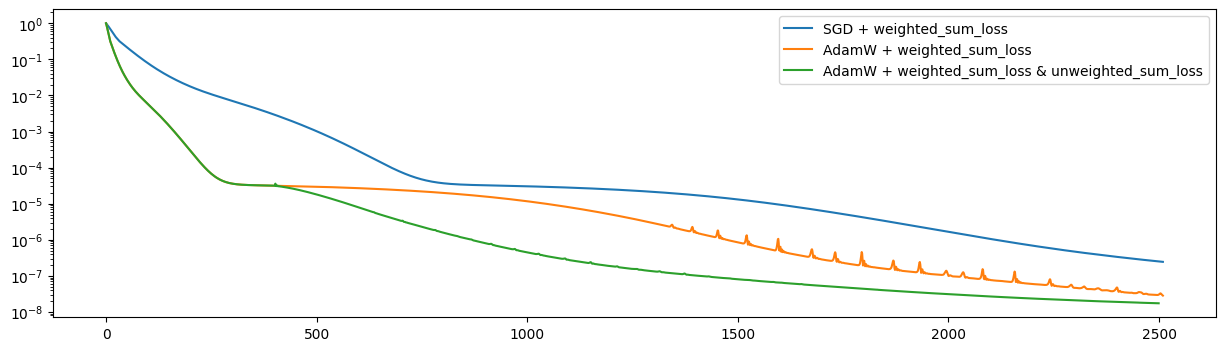

In [181]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses1)), rel_losses1, label='SGD + weighted_sum_loss')
ax.plot(range(0,len(rel_losses2)), rel_losses2, label='AdamW + weighted_sum_loss')
ax.plot(range(0,len(rel_losses3_2)), rel_losses3_2, label='AdamW + weighted_sum_loss & unweighted_sum_loss')

ax.set_yscale('log')
ax.legend()
plt.show()